In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ufc_pred_model.config import DATA_PATHS,PROJECT_ROOT

df = pd.read_csv(DATA_PATHS["large_dir"] / "large_dataset.csv")

df.head()

,event_name,r_fighter,b_fighter,winner,weight_class,is_title_bout,gender,method,finish_round,total_rounds,...,weight_diff,reach_diff,SLpM_total_diff,SApM_total_diff,sig_str_acc_total_diff,td_acc_total_diff,str_def_total_diff,td_def_total_diff,sub_avg_diff,td_avg_diff
0,UFC Fight Night: Ribas vs. Namajunas,Amanda Ribas,Rose Namajunas,Blue,Women's Flyweight,0,Women,Decision - Unanimous,5,5.0,...,0.00,2.54,0.94,-0.11,-0.01,0.04,-0.02,0.26,0.2,0.69
1,UFC Fight Night: Ribas vs. Namajunas,Karl Williams,Justin Tafa,Red,Heavyweight,0,Men,Decision - Unanimous,3,3.0,...,-13.16,12.70,-1.22,-3.32,-0.02,0.50,0.13,0.50,0.2,4.75
2,UFC Fight Night: Ribas vs. Namajunas,Edmen Shahbazyan,AJ Dobson,Red,Middleweight,0,Men,KO/TKO,1,3.0,...,0.00,-2.54,-0.69,-1.22,0.06,-0.37,-0.01,-0.02,0.3,0.57
3,UFC Fight Night: Ribas vs. Namajunas,Payton Talbott,Cameron Saaiman,Red,Bantamweight,0,Men,KO/TKO,2,3.0,...,0.00,7.62,2.73,-0.60,0.08,-0.28,0.00,0.43,-0.2,-0.91
4,UFC Fight Night: Ribas vs. Namajunas,Billy Quarantillo,Youssef Zalal,Blue,Featherweight,0,Men,Submission,2,3.0,...,0.00,-5.08,4.48,3.84,0.07,-0.11,-0.22,0.01,-0.2,-1.04


In [2]:
df.columns

Index(['event_name', 'r_fighter', 'b_fighter', 'winner', 'weight_class',
       'is_title_bout', 'gender', 'method', 'finish_round', 'total_rounds',
       'time_sec', 'referee', 'r_kd', 'r_sig_str', 'r_sig_str_att',
       'r_sig_str_acc', 'r_str', 'r_str_att', 'r_str_acc', 'r_td', 'r_td_att',
       'r_td_acc', 'r_sub_att', 'r_rev', 'r_ctrl_sec', 'r_wins_total',
       'r_losses_total', 'r_age', 'r_height', 'r_weight', 'r_reach',
       'r_stance', 'r_SLpM_total', 'r_SApM_total', 'r_sig_str_acc_total',
       'r_td_acc_total', 'r_str_def_total', 'r_td_def_total', 'r_sub_avg',
       'r_td_avg', 'b_kd', 'b_sig_str', 'b_sig_str_att', 'b_sig_str_acc',
       'b_str', 'b_str_att', 'b_str_acc', 'b_td', 'b_td_att', 'b_td_acc',
       'b_sub_att', 'b_rev', 'b_ctrl_sec', 'b_wins_total', 'b_losses_total',
       'b_age', 'b_height', 'b_weight', 'b_reach', 'b_stance', 'b_SLpM_total',
       'b_SApM_total', 'b_sig_str_acc_total', 'b_td_acc_total',
       'b_str_def_total', 'b_td_def_total', 'b_

## Dataset Column Descriptions

### Fight Information

| Column | Description |
|---|---|
| `event_name` | Name of the UFC event. |
| `r_fighter` | Red-corner fighter's name. |
| `b_fighter` | Blue-corner fighter's name. |
| `winner` | Winning corner: `Red` or `Blue`. |
| `weight_class` | Weight division of the fight. |
| `is_title_bout` | Indicates whether the fight was for a title. |
| `gender` | Fighter category, such as Men or Women. |
| `method` | Method by which the fight ended. |
| `finish_round` | Round in which the fight ended. |
| `total_rounds` | Scheduled number of rounds. |
| `time_sec` | Fight duration in seconds. |
| `referee` | Referee officiating the fight. |

### Red-Corner Fighter Statistics

| Column | Description |
|---|---|
| `r_kd` | Red fighter's knockdowns. |
| `r_sig_str` | Red fighter's significant strikes landed. |
| `r_sig_str_att` | Red fighter's significant strikes attempted. |
| `r_sig_str_acc` | Red fighter's significant-strike accuracy. |
| `r_str` | Red fighter's total strikes landed. |
| `r_str_att` | Red fighter's total strikes attempted. |
| `r_str_acc` | Red fighter's total-strike accuracy. |
| `r_td` | Red fighter's takedowns landed. |
| `r_td_att` | Red fighter's takedown attempts. |
| `r_td_acc` | Red fighter's takedown accuracy. |
| `r_sub_att` | Red fighter's submission attempts. |
| `r_rev` | Red fighter's reversals. |
| `r_ctrl_sec` | Red fighter's control time in seconds. |
| `r_wins_total` | Red fighter's total career wins before the fight. |
| `r_losses_total` | Red fighter's total career losses before the fight. |
| `r_age` | Red fighter's age. |
| `r_height` | Red fighter's height. |
| `r_weight` | Red fighter's weight. |
| `r_reach` | Red fighter's reach. |
| `r_stance` | Red fighter's fighting stance. |
| `r_SLpM_total` | Red fighter's historical significant strikes landed per minute. |
| `r_SApM_total` | Red fighter's historical significant strikes absorbed per minute. |
| `r_sig_str_acc_total` | Red fighter's historical significant-strike accuracy. |
| `r_td_acc_total` | Red fighter's historical takedown accuracy. |
| `r_str_def_total` | Red fighter's historical striking defense. |
| `r_td_def_total` | Red fighter's historical takedown defense. |
| `r_sub_avg` | Red fighter's average submissions per fight. |
| `r_td_avg` | Red fighter's average takedowns per fight. |

### Blue-Corner Fighter Statistics

The `b_` columns contain the same metrics as the corresponding `r_` columns, but for the blue-corner fighter.

| Column | Description |
|---|---|
| `b_kd` | Blue fighter's knockdowns. |
| `b_sig_str` | Blue fighter's significant strikes landed. |
| `b_sig_str_att` | Blue fighter's significant strikes attempted. |
| `b_sig_str_acc` | Blue fighter's significant-strike accuracy. |
| `b_str` | Blue fighter's total strikes landed. |
| `b_str_att` | Blue fighter's total strikes attempted. |
| `b_str_acc` | Blue fighter's total-strike accuracy. |
| `b_td` | Blue fighter's takedowns landed. |
| `b_td_att` | Blue fighter's takedown attempts. |
| `b_td_acc` | Blue fighter's takedown accuracy. |
| `b_sub_att` | Blue fighter's submission attempts. |
| `b_rev` | Blue fighter's reversals. |
| `b_ctrl_sec` | Blue fighter's control time in seconds. |
| `b_wins_total` | Blue fighter's total career wins before the fight. |
| `b_losses_total` | Blue fighter's total career losses before the fight. |
| `b_age` | Blue fighter's age. |
| `b_height` | Blue fighter's height. |
| `b_weight` | Blue fighter's weight. |
| `b_reach` | Blue fighter's reach. |
| `b_stance` | Blue fighter's fighting stance. |
| `b_SLpM_total` | Blue fighter's historical significant strikes landed per minute. |
| `b_SApM_total` | Blue fighter's historical significant strikes absorbed per minute. |
| `b_sig_str_acc_total` | Blue fighter's historical significant-strike accuracy. |
| `b_td_acc_total` | Blue fighter's historical takedown accuracy. |
| `b_str_def_total` | Blue fighter's historical striking defense. |
| `b_td_def_total` | Blue fighter's historical takedown defense. |
| `b_sub_avg` | Blue fighter's average submissions per fight. |
| `b_td_avg` | Blue fighter's average takedowns per fight. |

### Red–Blue Difference Features

Difference columns generally represent the red-corner value minus the blue-corner value.

| Column | Description |
|---|---|
| `kd_diff` | Difference in knockdowns. |
| `sig_str_diff` | Difference in significant strikes landed. |
| `sig_str_att_diff` | Difference in significant-strike attempts. |
| `sig_str_acc_diff` | Difference in significant-strike accuracy. |
| `str_diff` | Difference in total strikes landed. |
| `str_att_diff` | Difference in total-strike attempts. |
| `str_acc_diff` | Difference in total-strike accuracy. |
| `td_diff` | Difference in takedowns landed. |
| `td_att_diff` | Difference in takedown attempts. |
| `td_acc_diff` | Difference in takedown accuracy. |
| `sub_att_diff` | Difference in submission attempts. |
| `rev_diff` | Difference in reversals. |
| `ctrl_sec_diff` | Difference in control time, in seconds. |
| `wins_total_diff` | Difference in total career wins. |
| `losses_total_diff` | Difference in total career losses. |
| `age_diff` | Difference in fighter age. |
| `height_diff` | Difference in height. |
| `weight_diff` | Difference in weight. |
| `reach_diff` | Difference in reach. |
| `SLpM_total_diff` | Difference in historical significant strikes landed per minute. |
| `SApM_total_diff` | Difference in historical significant strikes absorbed per minute. |
| `sig_str_acc_total_diff` | Difference in historical significant-strike accuracy. |
| `td_acc_total_diff` | Difference in historical takedown accuracy. |
| `str_def_total_diff` | Difference in historical striking defense. |
| `td_def_total_diff` | Difference in historical takedown defense. |
| `sub_avg_diff` | Difference in average submissions per fight. |
| `td_avg_diff` | Difference in average takedowns per fight. |

In [3]:
df.describe()

,is_title_bout,finish_round,total_rounds,time_sec,r_kd,r_sig_str,r_sig_str_att,r_sig_str_acc,r_str,r_str_att,...,weight_diff,reach_diff,SLpM_total_diff,SApM_total_diff,sig_str_acc_total_diff,td_acc_total_diff,str_def_total_diff,td_def_total_diff,sub_avg_diff,td_avg_diff
count,7439.000000,7439.000000,7408.000000,7439.000000,7439.000000,7439.000000,7439.000000,7439.000000,7439.000000,7439.000000,...,7439.000000,6401.000000,7439.000000,7439.000000,7439.000000,7439.000000,7439.000000,7439.000000,7439.000000,7439.000000
mean,0.055787,2.336336,3.128915,227.016669,0.249227,38.361204,83.786262,0.475335,58.199892,106.374916,...,0.171000,0.190073,0.142594,-0.171643,0.012109,0.028164,0.020909,0.037513,0.045651,0.134487
std,0.229525,1.015243,0.652739,98.169665,0.524210,32.871278,71.381806,0.165935,46.057503,79.812210,...,6.774199,8.252628,1.585610,1.691358,0.119919,0.276307,0.113455,0.292107,1.052065,1.781598
min,0.000000,1.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-258.550000,-27.940000,-8.990000,-39.490000,-0.700000,-1.000000,-0.580000,-1.000000,-15.100000,-11.770000
25%,0.000000,1.000000,3.000000,149.000000,0.000000,14.000000,29.000000,0.370000,22.000000,40.000000,...,0.000000,-5.080000,-0.860000,-1.040000,-0.060000,-0.130000,-0.040000,-0.140000,-0.400000,-0.870000
50%,0.000000,3.000000,3.000000,287.000000,0.000000,31.000000,66.000000,0.470000,50.000000,94.000000,...,0.000000,0.000000,0.130000,-0.120000,0.010000,0.020000,0.010000,0.020000,0.000000,0.090000
75%,0.000000,3.000000,3.000000,300.000000,0.000000,54.000000,120.000000,0.570000,83.000000,156.000000,...,0.000000,5.080000,1.160000,0.790000,0.080000,0.190000,0.080000,0.210000,0.500000,1.160000
max,1.000000,5.000000,5.000000,1080.000000,5.000000,445.000000,744.000000,1.000000,447.000000,746.000000,...,52.160000,33.020000,18.780000,12.640000,0.830000,1.000000,0.720000,1.000000,13.800000,11.110000


In [4]:
df.isna().sum()

event_name            0
r_fighter             0
b_fighter             0
winner                0
weight_class          0
                     ..
td_acc_total_diff     0
str_def_total_diff    0
td_def_total_diff     0
sub_avg_diff          0
td_avg_diff           0
Length: 95, dtype: int64

In [5]:
df[df["total_rounds"].isna()]

,event_name,r_fighter,b_fighter,winner,weight_class,is_title_bout,gender,method,finish_round,total_rounds,...,weight_diff,reach_diff,SLpM_total_diff,SApM_total_diff,sig_str_acc_total_diff,td_acc_total_diff,str_def_total_diff,td_def_total_diff,sub_avg_diff,td_avg_diff
7408,UFC 4: Revenge of the Warriors,Royce Gracie,Dan Severn,Red,UFC 4 Tournament Title,1,Men,Submission,1,NaN,...,-34.02,NaN,0.88,1.13,0.41,0.0,0.37,0.66,0.8,0.00
7409,UFC 4: Revenge of the Warriors,Dan Severn,Marcus Bossett,Red,Open Weight,0,Men,Submission,1,NaN,...,15.88,NaN,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00
7410,UFC 4: Revenge of the Warriors,Royce Gracie,Keith Hackney,Red,Open Weight,0,Men,Submission,1,NaN,...,-11.34,NaN,0.88,1.13,0.41,0.0,0.37,0.66,0.8,0.00
7411,UFC 4: Revenge of the Warriors,Dan Severn,Anthony Macias,Red,Open Weight,0,Men,Submission,1,NaN,...,29.49,NaN,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00
7412,UFC 4: Revenge of the Warriors,Steve Jennum,Melton Bowen,Red,Open Weight,0,Men,Submission,1,NaN,...,-4.54,NaN,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00
7413,UFC 4: Revenge of the Warriors,Keith Hackney,Joe Son,Red,Open Weight,0,Men,Submission,1,NaN,...,-16.33,NaN,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00
7414,UFC 4: Revenge of the Warriors,Royce Gracie,Ron van Clief,Red,Open Weight,0,Men,Submission,1,NaN,...,-6.80,NaN,0.88,1.13,0.41,0.0,0.37,0.66,0.8,0.00
7415,UFC 4: Revenge of the Warriors,Guy Mezger,Jason Fairn,Red,Open Weight,0,Men,KO/TKO,1,NaN,...,-13.61,NaN,2.30,1.36,0.32,0.5,0.72,0.88,0.0,0.39
7416,UFC 4: Revenge of the Warriors,Marcus Bossett,Eldo Xavier Dias,Red,Open Weight,0,Men,KO/TKO,1,NaN,...,15.87,NaN,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00
7417,UFC 4: Revenge of the Warriors,Joe Charles,Kevin Rosier,Red,Open Weight,0,Men,Submission,1,NaN,...,-6.81,NaN,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00


In [6]:
df["total_rounds"] = df["total_rounds"].fillna(1)

In [7]:
df.isna().sum()

event_name            0
r_fighter             0
b_fighter             0
winner                0
weight_class          0
                     ..
td_acc_total_diff     0
str_def_total_diff    0
td_def_total_diff     0
sub_avg_diff          0
td_avg_diff           0
Length: 95, dtype: int64

In [8]:
df[df['referee'].isna()]

,event_name,r_fighter,b_fighter,winner,weight_class,is_title_bout,gender,method,finish_round,total_rounds,...,weight_diff,reach_diff,SLpM_total_diff,SApM_total_diff,sig_str_acc_total_diff,td_acc_total_diff,str_def_total_diff,td_def_total_diff,sub_avg_diff,td_avg_diff
265,UFC Fight Night: Holloway vs. The Korean Zombie,Max Holloway,Chan Sung Jung,Red,Featherweight,0,Men,KO/TKO,3,5.0,...,0.00,-7.62,3.24,0.23,0.06,0.09,0.07,0.12,-0.3,-0.43
1529,UFC Fight Night: Edwards vs. Muhammad,Manel Kape,Matheus Nicolau,Blue,Flyweight,0,Men,Decision - Split,3,3.0,...,0.00,5.08,1.46,1.37,0.01,-0.08,-0.07,-0.16,-0.5,-0.83
1652,UFC Fight Night: Hermansson vs. Vettori,Gabriel Benitez,Justin Jaynes,Red,Lightweight,0,Men,KO/TKO,1,3.0,...,4.54,7.62,1.58,-1.07,-0.03,0.10,0.00,0.35,-0.1,-0.51
1747,UFC Fight Night: Holm vs. Aldana,Germaine de Randamie,Julianna Pena,Red,Women's Bantamweight,0,Women,Submission,3,3.0,...,0.00,5.08,-0.44,-0.16,-0.01,-0.55,0.15,0.46,-0.4,-1.94
1810,UFC Fight Night: Munhoz vs. Edgar,Mariya Agapova,Shana Dobson,Blue,Women's Flyweight,0,Women,KO/TKO,2,3.0,...,0.00,-2.54,1.33,-1.38,0.18,0.16,0.02,0.33,0.9,-0.25
1847,UFC Fight Night: Whittaker vs. Till,Fabricio Werdum,Alexander Gustafsson,Red,Heavyweight,0,Men,Submission,1,3.0,...,11.79,-5.08,-0.44,-0.89,0.12,-0.08,0.04,-0.52,0.8,0.22
1905,UFC Fight Night: Blaydes vs. Volkov,Curtis Blaydes,Alexander Volkov,Red,Heavyweight,0,Men,Decision - Unanimous,5,5.0,...,6.80,0.00,-1.57,-1.17,-0.07,-0.10,0.05,-0.42,-0.2,5.23
1962,UFC Fight Night: Smith vs. Teixeira,Ricky Simon,Ray Borg,Red,Bantamweight,0,Men,Decision - Split,3,3.0,...,0.00,15.24,1.49,1.68,-0.09,-0.04,0.13,0.30,-0.6,1.60
2031,UFC Fight Night: Anderson vs. Blachowicz,Lando Vannata,Yancy Medeiros,Red,Lightweight,0,Men,Decision - Unanimous,3,3.0,...,0.00,-10.16,0.16,-0.91,0.08,-0.13,0.08,-0.04,-0.4,0.76
2236,UFC 242: Khabib vs. Poirier,Omari Akhmedov,Zak Cummings,Red,Middleweight,0,Men,Decision - Unanimous,3,3.0,...,-9.08,-5.08,0.01,-0.07,-0.01,0.17,0.00,-0.01,-0.4,1.96


In [9]:
df['referee'] = df['referee'].fillna("Unknown referee")

In [10]:
# impute age by gender
for column in ("r_age", "b_age"):
    df[column] = df[column].fillna(df.groupby("gender")[column].transform("mean"))

In [11]:
print(df[["r_age", "b_age"]].isna().sum())

r_age    0
b_age    0
dtype: int64


In [12]:
df.isna().sum()

event_name            0
r_fighter             0
b_fighter             0
winner                0
weight_class          0
                     ..
td_acc_total_diff     0
str_def_total_diff    0
td_def_total_diff     0
sub_avg_diff          0
td_avg_diff           0
Length: 95, dtype: int64

In [13]:
# mean imputed reach for r and b reach columns
for column in ("r_reach", "b_reach"):
    df[column] = df[column].fillna(df[column].mean())

In [14]:
df['r_reach'].isna().sum(), df['b_reach'].isna().sum()

(np.int64(0), np.int64(0))

C:\Users\dparh\AppData\Local\Temp\ipykernel_3304\1139615942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=df, palette="Set2")


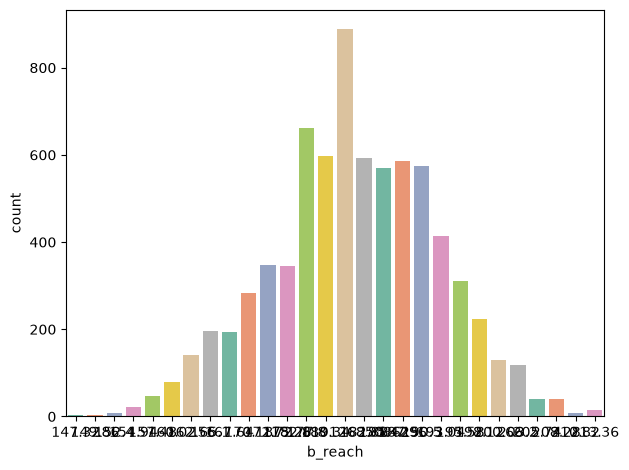

In [15]:
columns = ["r_stance", 'b_stance']

sns.countplot(x=column, data=df, palette="Set2")
plt.tight_layout()

plt.show()

In [16]:
# assign weights to each stance based on their distribution in the dataset

stance_cols = ["r_stance", "b_stance"]
stance_probs = (
    df[stance_cols].stack().value_counts(normalize=True)
)
rng = np.random.default_rng()  # create a random number generator with a fixed seed for reproducibility

# now fill na's with random stances based on the weights
for column in stance_cols:
    missing = df[column].isna()
    df.loc[missing, column] = rng.choice(
        stance_probs.index.to_numpy(),
        size=missing.sum(),
        p=stance_probs.to_numpy()
    )

In [17]:
df['r_stance'].isna().sum(), df['b_stance'].isna().sum()

(np.int64(0), np.int64(0))

In [18]:
df.isna().sum()

event_name            0
r_fighter             0
b_fighter             0
winner                0
weight_class          0
                     ..
td_acc_total_diff     0
str_def_total_diff    0
td_def_total_diff     0
sub_avg_diff          0
td_avg_diff           0
Length: 95, dtype: int64

Handle missing age diffs

In [19]:
# impute ages by gender
df['age_diff'] = df['r_age'] - df['b_age']

In [20]:
df['age_diff'].isna().sum()

np.int64(0)

In [21]:
df.isna().sum()

event_name            0
r_fighter             0
b_fighter             0
winner                0
weight_class          0
                     ..
td_acc_total_diff     0
str_def_total_diff    0
td_def_total_diff     0
sub_avg_diff          0
td_avg_diff           0
Length: 95, dtype: int64

In [22]:
df['reach_diff'] = df['r_reach'] - df['b_reach']

In [23]:
df.isna().sum()

event_name            0
r_fighter             0
b_fighter             0
winner                0
weight_class          0
                     ..
td_acc_total_diff     0
str_def_total_diff    0
td_def_total_diff     0
sub_avg_diff          0
td_avg_diff           0
Length: 95, dtype: int64

In [25]:
df.to_csv(PROJECT_ROOT / "data" / "large_clean.csv")